# 13. Model Error Analysis

This notebook continues the local CIFAR-10 and fine-tuned ResNet-18 work from notebooks 10–11. We inspect wrong predictions to ask not only **what** the model got wrong, but also what may have contributed to the mistake.


## 1. Errors by class

Some classes may be harder for the model than others. Per-class recall tells us what fraction of each actual class was correctly predicted; low recall means more missed examples for that class.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
data, checkpoint = Path("data"), Path("artifacts/resnet18_cifar10_finetuned.pth")
if not (data / "cifar-10-batches-py").exists() or not checkpoint.exists():
    raise FileNotFoundError("Need local CIFAR-10 data and the notebook 10 checkpoint.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
prep = transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor(),
    transforms.Normalize((.485, .456, .406), (.229, .224, .225))])
test = datasets.CIFAR10(data, train=False, download=False, transform=prep)
model = models.resnet18(weights=None); model.fc = torch.nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
model.to(device).eval()
actual, predicted = [], []
with torch.inference_mode():
    for x, y in DataLoader(test, batch_size=64):
        predicted.extend(model(x.to(device)).argmax(1).cpu().numpy()); actual.extend(y.numpy())
actual, predicted = np.array(actual), np.array(predicted)
errors = np.flatnonzero(actual != predicted)
print(f"Accuracy: {(actual == predicted).mean():.1%} | wrong predictions: {len(errors)}")

Accuracy: 84.0% | wrong predictions: 1596


In [2]:
names = test.classes
matrix = confusion_matrix(actual, predicted)
display(pd.DataFrame({"Class": names, "Errors": matrix.sum(1) - matrix.diagonal(),
    "Recall": (matrix.diagonal() / matrix.sum(1)).round(2)}).sort_values("Recall"))
pairs = sorted([(names[a], names[p], matrix[a, p]) for a in range(10)
    for p in range(10) if a != p], key=lambda row: row[2], reverse=True)
display(pd.DataFrame(pairs[:5], columns=["Actual", "Predicted", "Errors"]))

,Class,Errors,Recall
3,cat,267,0.73
2,bird,233,0.77
5,dog,217,0.78
4,deer,202,0.80
7,horse,175,0.82
1,automobile,107,0.89
6,frog,114,0.89
8,ship,111,0.89
0,airplane,95,0.90
9,truck,75,0.92


,Actual,Predicted,Errors
0,dog,cat,119
1,cat,dog,111
2,automobile,truck,81
3,bird,airplane,65
4,bird,deer,61


## 2. Image quality

Blur or low detail can hide useful features. CIFAR-10 has no image-quality labels, so look at the error examples before concluding that image quality caused a mistake.


## 3. Image size

Every CIFAR-10 image is 32 × 32 pixels, so image dimensions do not vary in this dataset. Objects can still appear small within an image, making their details difficult to recognize.


## 4. Orientation

A viewpoint that differs from training examples may confuse the model. Inspect the error gallery for unusual angles; CIFAR-10 does not label orientation or camera view.


## 5. Background

The model may use background colors or scene context instead of the object alone. Look for distracting scenes in the gallery; CIFAR-10 has no background annotations, so this is only a possible explanation.


## 6. Similar-looking classes

Classes with similar shapes, colors, or textures may be confused. The ranked actual-to-predicted class pairs above show the most frequent mix-ups and give concrete examples to inspect.


## 7. Occlusion

An object partly hidden by another object may lose important features. Check the error images for blocked objects; the dataset does not mark which images are occluded.


## 8. Noise

Visual noise or compression artifacts can obscure object details. Look for noisy examples in the gallery; CIFAR-10 does not label noise levels, so do not assume it caused an error without evidence.


## Inspect the wrong predictions

Compare the actual and predicted labels with the image. The gallery helps you decide whether a possible issue above is visible in the examples.

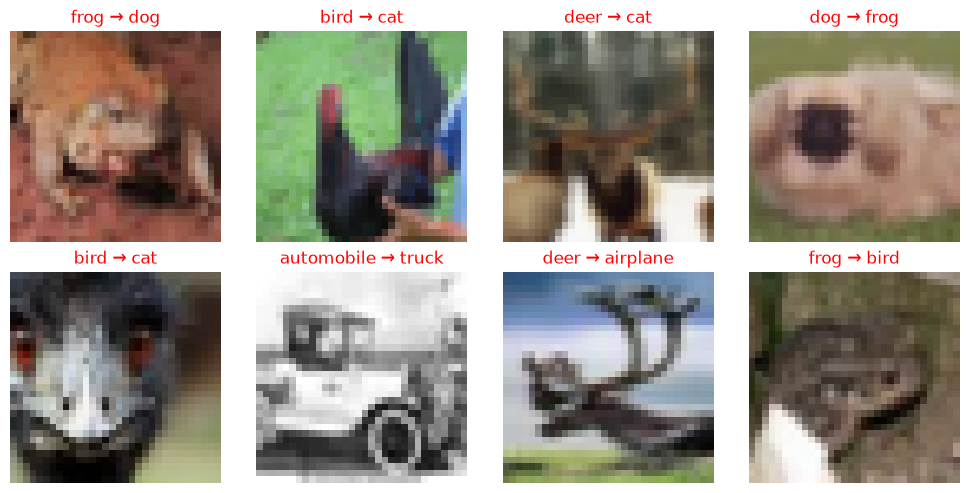

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, i in zip(axes.flat, errors[:8]):
    ax.imshow(test.data[i]); ax.set_title(f"{names[actual[i]]} → {names[predicted[i]]}", color="red"); ax.axis("off")
for ax in axes.flat[min(len(errors), 8):]: ax.axis("off")
plt.tight_layout(); plt.show()

## Error-analysis table

Use this table to turn observed mistakes into explanations and possible next steps. For image conditions that are not labelled, verify the possible cause by inspecting multiple examples first.

In [4]:
worst = int(np.argmin(matrix.diagonal() / matrix.sum(1)))
pair = pairs[0]
display(pd.DataFrame([
    ["Class", f"{names[worst]} has the lowest recall", "Class features may be hard to learn", "More errors for this class", "Add varied examples of this class"],
    ["Image quality", "Blurry or unclear image (inspect gallery)", "Useful details may be hidden", "Harder recognition", "Use clearer images or quality augmentation"],
    ["Size", "All images are 32 × 32; object may look small", "Object has few visible pixels", "Details can disappear", "Use higher-resolution images if available"],
    ["Orientation", "Unusual view (inspect gallery)", "View differs from training examples", "Unfamiliar angles may fail", "Use realistic rotation augmentation"],
    ["Background", "Distracting scene (inspect gallery)", "Model may rely on scene context", "New scenes may cause errors", "Train with varied backgrounds"],
    ["Similar-looking classes", f"{pair[0]} → {pair[1]} ({pair[2]} errors)", "Classes share visual features", "Repeated class mix-ups", "Add examples that highlight differences"],
    ["Occlusion", "Partly hidden object (inspect gallery)", "Important object parts are blocked", "Incomplete objects may be missed", "Use realistic occlusion augmentation"],
    ["Noise", "Noisy image (inspect gallery)", "Noise may hide useful details", "Less reliable predictions", "Use realistic noise augmentation"],
], columns=["Error Type", "Example", "Possible Cause", "Impact", "Proposed Improvement"]))

,Error Type,Example,Possible Cause,Impact,Proposed Improvement
0,Class,cat has the lowest recall,Class features may be hard to learn,More errors for this class,Add varied examples of this class
1,Image quality,Blurry or unclear image (inspect gallery),Useful details may be hidden,Harder recognition,Use clearer images or quality augmentation
2,Size,All images are 32 × 32; object may look small,Object has few visible pixels,Details can disappear,Use higher-resolution images if available
3,Orientation,Unusual view (inspect gallery),View differs from training examples,Unfamiliar angles may fail,Use realistic rotation augmentation
4,Background,Distracting scene (inspect gallery),Model may rely on scene context,New scenes may cause errors,Train with varied backgrounds
5,Similar-looking classes,dog → cat (119 errors),Classes share visual features,Repeated class mix-ups,Add examples that highlight differences
6,Occlusion,Partly hidden object (inspect gallery),Important object parts are blocked,Incomplete objects may be missed,Use realistic occlusion augmentation
7,Noise,Noisy image (inspect gallery),Noise may hide useful details,Less reliable predictions,Use realistic noise augmentation


## Conclusion

Class scores and confused pairs show **where** errors occur. The gallery helps inspect **what** they look like. Use visual evidence to test possible causes; do not treat an unlabelled image condition as a confirmed explanation.